# Lab 1: Statistical Foundations & Classical Models (Student Version)

## Objective
Apply concepts from Lecture 1 to the Comprehensive BTC/USD 1M Dataset:
1. Data Preprocessing & Resampling.
2. Time Series Decomposition.
3. Testing for Stationarity (ADF Test).
4. Interpreting ACF and PACF plots.
5. Building and evaluating an ARIMA model.

### Task 1: Import Necessary Libraries
Import the standard data science and time-series libraries you will need.

In [1]:
#check GPU is exisit
import torch
if torch.cuda.is_available():
    print("GPU is available")
else:    print("GPU is not available")

GPU is available


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TODO 1: Import the following from statsmodels:
# - seasonal_decompose
# - adfuller (for ADF test)
# - plot_acf, plot_pacf
# - ARIMA
# Your imports here:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['axes.grid'] = True

### Task 2: Load the Dataset
We are using the `imranbukhari/comprehensive-btcusd-1m-data` dataset from Kaggle. Run the cell below to download it (if you haven't already).
- We interested in ***Closed***  Price ONLY

In [3]:
# Uncomment and run this if you are using kagglehub to download the dataset directly.
import kagglehub
path = kagglehub.dataset_download("imranbukhari/comprehensive-btcusd-1m-data")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'comprehensive-btcusd-1m-data' dataset.
Path to dataset files: /kaggle/input/comprehensive-btcusd-1m-data


In [4]:
#know ectach file path
import os
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))
        

/kaggle/input/comprehensive-btcusd-1m-data/BTCUSD_1m_BitMEX.csv
/kaggle/input/comprehensive-btcusd-1m-data/BTCUSD_1m_Coinbase.csv
/kaggle/input/comprehensive-btcusd-1m-data/BTCUSD_1m_Binance.csv
/kaggle/input/comprehensive-btcusd-1m-data/BTCUSD_1m_KuCoin.csv
/kaggle/input/comprehensive-btcusd-1m-data/BTCUSD_1m_Bitfinex.csv
/kaggle/input/comprehensive-btcusd-1m-data/BTCUSD_1m_Bitstamp.csv
/kaggle/input/comprehensive-btcusd-1m-data/BTCUSD_1m_BinanceFutures.csv
/kaggle/input/comprehensive-btcusd-1m-data/BTCUSD_1m_Combined_Index.csv
/kaggle/input/comprehensive-btcusd-1m-data/BTCUSD_1m_OKX.csv


In [5]:
# TODO 2: Load the dataset using pandas.
# Replace 'YOUR_FILE_NAME.csv' with the actual file name found in your dataset path.
df = pd.read_csv(path + "/BTCUSD_1m_Combined_Index.csv")
# Print the first 5 rows to inspect the columns.
df.head()

,Open time,Volume,Open,High,Low,Close
0,2011-08-18 12:37:00,0.489908,10.9,10.9,10.9,10.9
1,2011-08-18 12:38:00,0.000000,10.9,10.9,10.9,10.9
2,2011-08-18 12:39:00,0.000000,10.9,10.9,10.9,10.9
3,2011-08-18 12:40:00,0.000000,10.9,10.9,10.9,10.9
4,2011-08-18 12:41:00,0.000000,10.9,10.9,10.9,10.9


### Task 3: Data Preprocessing & Resampling
The dataset contains 1-minute frequency data, which is too granular and noisy for standard ARIMA models. We need to aggregate this into daily data.

In [6]:
# TODO 3.1: Convert the time/date column to pandas datetime objects.
df["Open time"] = pd.to_datetime(df["Open time"])
# TODO 3.2: Set the datetime column as the index of the dataframe.
df.set_index("Open time", inplace=True)
btc_close = df["Close"]
# TODO 3.3: Resample the dataframe to a Daily frequency ('D'). 
btc_daily = btc_close.resample('D').last()

# TODO 3.4: Drop any missing values (NaNs) that might have resulted from resampling.
btc_daily.dropna(inplace=True)


In [7]:
#just to check the type of btc_daily
btc_daily=pd.DataFrame(btc_daily)

In [8]:
btc_daily

,Close
Open time,
2011-08-18,10.90
2011-08-19,11.69
2011-08-20,11.70
2011-08-21,11.70
2011-08-22,11.70
...,...
2025-10-07,121405.08
2025-10-08,123297.99
2025-10-09,121650.96


### Task 4: Visualize the Time Series
Let's visualize the daily closing price of BTC.

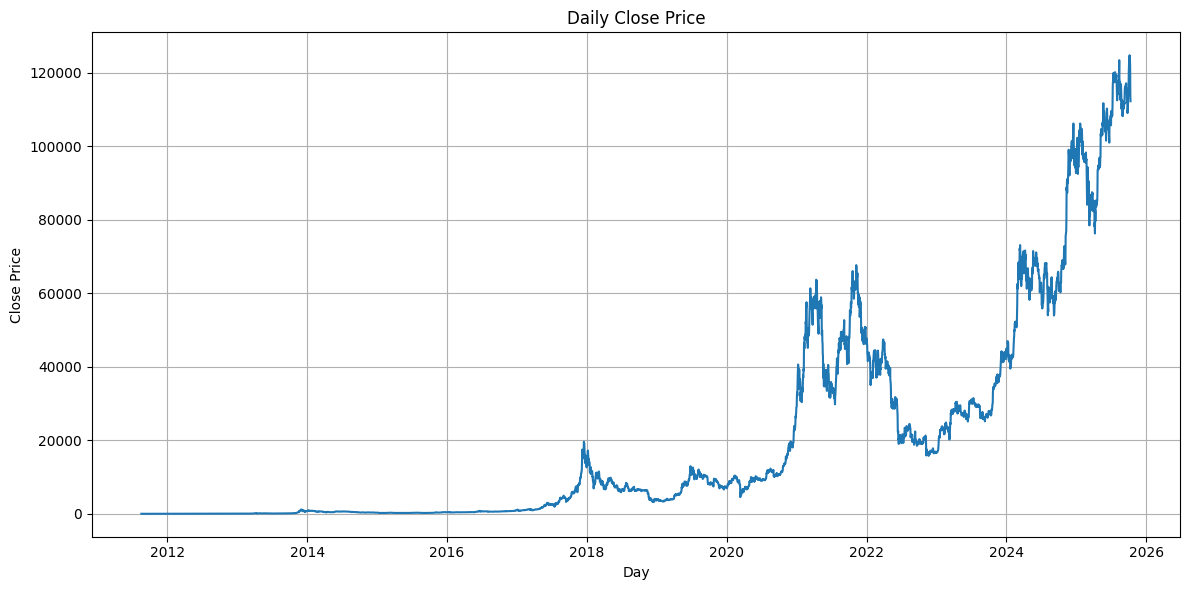

In [9]:
# TODO 4: Plot the daily BTC closing prices.
# Ensure your plot has a title, x-axis label, and y-axis label.
ax = plt.subplot()
ax.plot(btc_daily.index, btc_daily['Close'])
ax.set_title("Daily Close Price")
ax.set_xlabel("Day")
ax.set_ylabel("Close Price")
plt.tight_layout()
plt.show()

### initial look at the data pervious graphs were for the whole data but now we will focus on the daily data
#### Data is not stationary, we will apply log transformation to stabilize the variance and make it more suitable for ARIMA modeling.

### Task 5: Time Series Decomposition
Decompose the time series to observe its underlying components: Trend, Seasonality, and Residuals.

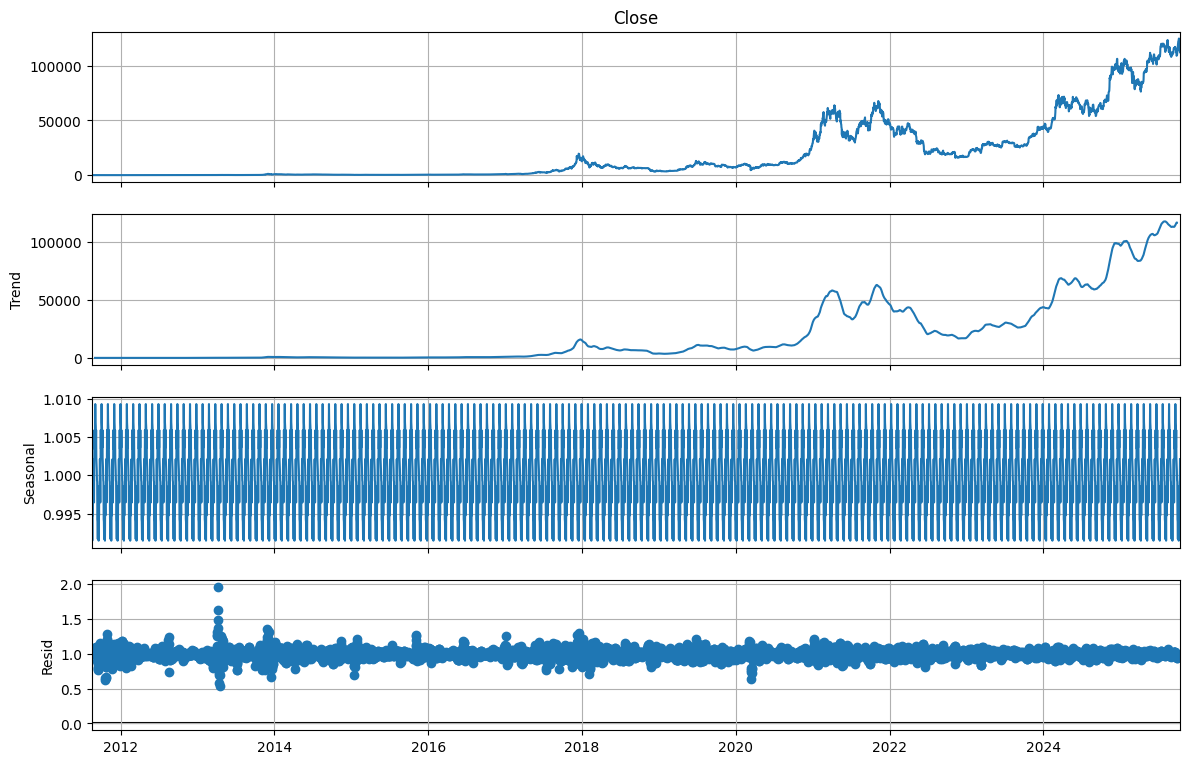

In [10]:
# TODO 5: Use `seasonal_decompose` on the daily closing prices.
# Set the period appropriately (e.g., period=30 for monthly seasonality on daily data, or period=365 for yearly).
decomposition = seasonal_decompose(btc_daily['Close'], model='multiplicative', period=30)

# Plot the decomposition.
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

#### from the decomposition we can see that there is a strong upward trend in the data, which is expected given the historical price of Bitcoin. The seasonal component shows some periodic fluctuations, but it is not very pronounced. The residuals appear to be relatively small compared to the trend, indicating that most of the variation in the data can be explained by the trend and seasonality.

### Task 6: Testing for Stationarity (ADF Test)
Before fitting an ARIMA model, we must check if our time series is stationary.

In [11]:
# TODO 6.1: Create a function or write code to perform the Augmented Dickey-Fuller (ADF) test.
# It should print the ADF Statistic and the p-value.
def adf_test(series):
    """ADF Reject Nulls When
    - Statistic < Critical Value(5%)
    - P-value < 0.05
    """
    result = adfuller(series, autolag='BIC')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f"Critical Values:")
    for k, v in  result[4].items():
        print(f"{k}: {v:.4f}")
    if result[1] < 0.05 and result[0] < result[4]['5%']:
        print("Result: Data is STATIONARY (Reject H0)")
    else:
        print("Result: Data is NON-STATIONARY (Fail to reject H0)")
# TODO 6.2: Run the ADF test on your `btc_daily` series.
# Question: Based on the p-value, is the series stationary? (Add your answer as a comment).
print("--- Raw Data Test ---")
adf_test(btc_daily['Close'])


--- Raw Data Test ---


ADF Statistic: 1.0462
p-value: 0.9947
Critical Values:
1%: -3.4316
5%: -2.8621
10%: -2.5671
Result: Data is NON-STATIONARY (Fail to reject H0)


### From the ADF test results, we can conclude that the time series is not stationary (p-value > 0.05). This means we need to apply differencing to make it stationary before fitting an ARIMA model.

### Task 7: Making the Series Stationary (Differencing)
If the series is not stationary, we need to apply differencing.

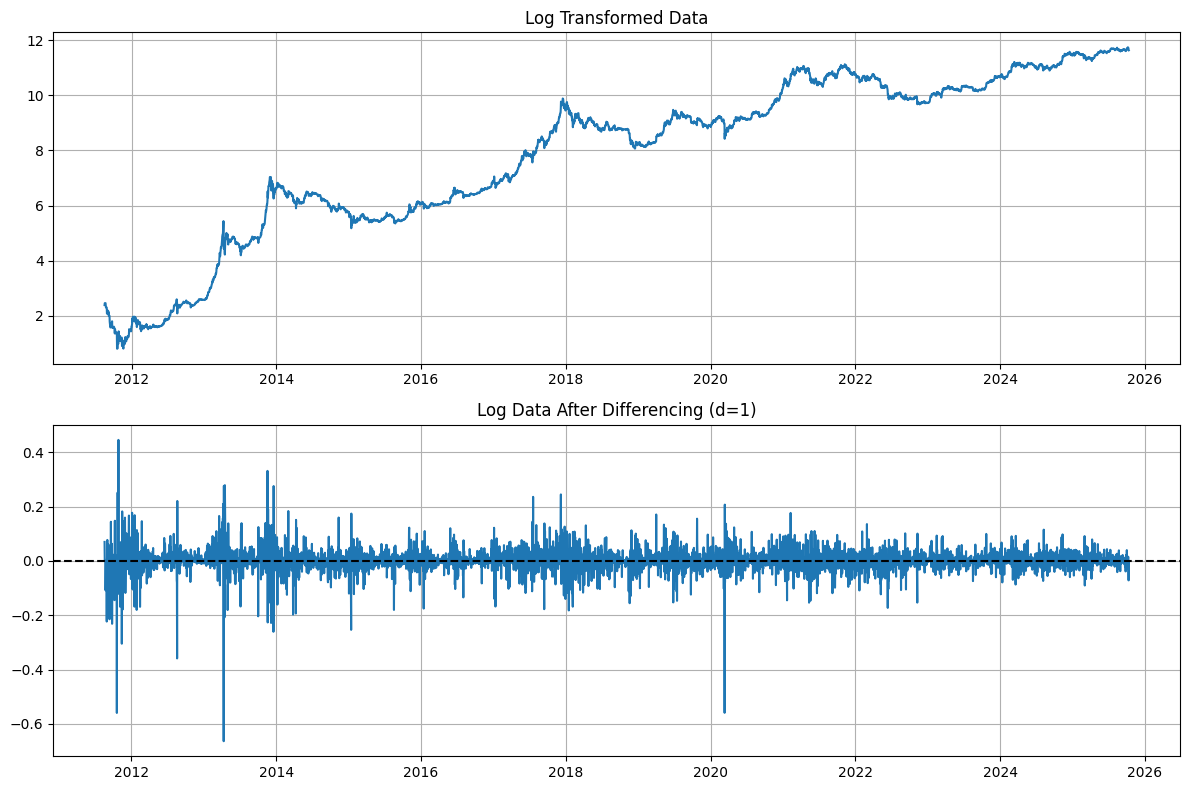

--- Differenced Log Data Test ---
ADF Statistic: -75.4891
p-value: 0.0000
Critical Values:
1%: -3.4316
5%: -2.8621
10%: -2.5671
Result: Data is STATIONARY (Reject H0)
--------------------------------------------------


In [12]:
# TODO 7.1: Apply first-order differencing (or log differencing) to the daily closing prices.
btc_daily["Log_Price"] = np.log(btc_daily["Close"])
btc_daily["Log_Diff"] = btc_daily["Log_Price"].diff().dropna()

# Remember to drop the NaN value created by differencing.

# TODO 7.2: Plot the differenced series.
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(btc_daily["Log_Price"])
axes[0].set_title('Log Transformed Data')

axes[1].plot(btc_daily["Log_Diff"])
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Log Data After Differencing (d=1)')

plt.tight_layout()
plt.show()
# TODO 7.3: Run the ADF test again on the differenced series to confirm it is now stationary.
print("--- Differenced Log Data Test ---")
adf_test(btc_daily["Log_Diff"].dropna())
print("-"*50)


### from the ADF test results, we can conclude that the differenced series is now stationary (p-value < 0.05). This means we can proceed with fitting an ARIMA model on the differenced data.

### Task 8: ACF and PACF Plots
Plot the Autocorrelation and Partial Autocorrelation functions to help determine the `p` (AR) and `q` (MA) parameters for the ARIMA model.

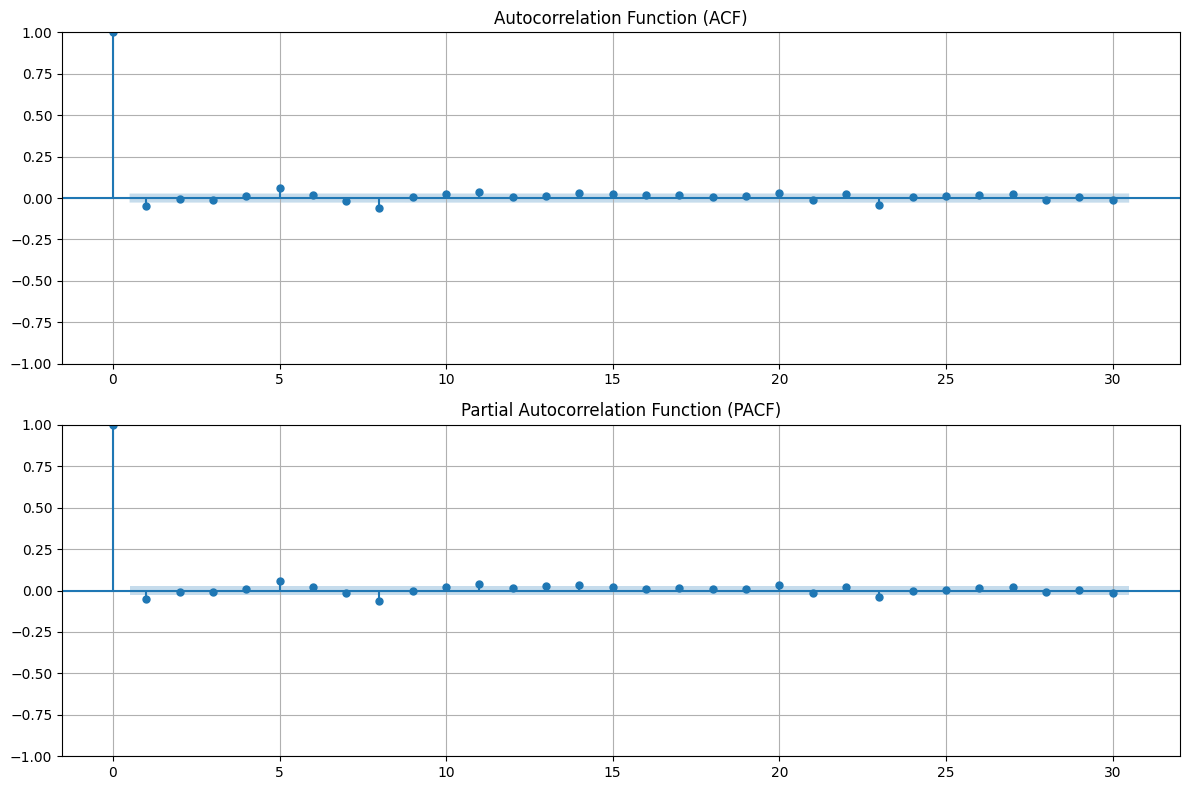

In [13]:
# TODO 8: Plot the ACF and PACF of the STATIONARY (differenced) series.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(btc_daily['Log_Diff'].dropna(), lags=30, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')

plot_pacf(btc_daily['Log_Diff'].dropna(), lags=30, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

### from ACF and PACF plots, we can see that the ACF plot shows a significant spike at lag 1, suggesting an MA(1) component. The PACF plot does not show any significant spikes, indicating that there may not be a strong AR component. Based on this analysis, we might consider an ARIMA(0,1,1) model for our time series.

In [ ]:
"""
from pervious find
- The data contain trend at this trend eliminated when make data stationary by apply differncing in log data
- There is no sesonallity at data after see ACF And PACF
- the best hyber - parameter is 
AR :
   p = 1
   P = 0
MA :
   q = 1
   Q = 0
Differicing = 1
"""

### Task 9: Building the ARIMA Model
Split the data into training and testing sets, then build the ARIMA model.

In [14]:
# TODO 9.1: Split the original `btc_daily` data into Train and Test sets.
# E.g., Use the last 60 days as the Test set, and everything before as Train.
train_ratio = 0.8
last_train_index = int(len(btc_daily) * train_ratio)
train = btc_daily.iloc[:last_train_index]
test  = btc_daily.iloc[last_train_index:]
# TODO 9.2: Initialize and fit an ARIMA model on the training data.
# Pass in the (p, d, q) order based on your previous findings. 
# Note: If you pass the original non-stationary `train` data, set `d=1`. 
model = ARIMA(train['Log_Price'], order=(0, 1, 1), seasonal_order=(0,0,0,0))
fitted_model = model.fit()

# Print the model summary.
print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:              Log_Price   No. Observations:                 4135
Model:                 ARIMA(0, 1, 1)   Log Likelihood                6656.865
Date:                Fri, 06 Mar 2026   AIC                         -13309.729
Time:                        12:26:31   BIC                         -13297.075
Sample:                    08-18-2011   HQIC                        -13305.251
                         - 12-12-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0481      0.006     -7.639      0.000      -0.060      -0.036
sigma2         0.0023   1.45e-05    160.716      0.000       0.002       0.002
Ljung-Box (L1) (Q):                   0.01   Jarque-

### Now, start using Auto ARIMA to find the best parameters for our model using the `pmdarima` library. and statsforecast library

In [15]:
#split data to train and test
train_ratio = 0.8
last_train_index = int(len(btc_daily) * train_ratio)
train = btc_daily.iloc[:last_train_index]
test  = btc_daily.iloc[last_train_index:]

In [16]:
! pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 18.1 MB/s eta 0:00:0000:01


#### First use pmdarima library to find the best parameters for our model

In [17]:
#try auto arima
from pmdarima import auto_arima
auto_model = auto_arima(train['Log_Price'], seasonal=False, trace=True)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-13308.199, Time=1.50 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-13305.826, Time=0.40 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-13313.743, Time=0.29 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-13313.932, Time=0.37 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-13302.225, Time=0.16 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-13312.209, Time=1.15 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-13312.221, Time=0.30 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-13310.210, Time=1.95 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-13309.729, Time=0.98 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 7.112 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 4135
Model:               SARIMAX(0, 1, 1)   Log Likelihood                6659.966
Date:                Fri, 06 Ma

In [18]:
! pip install statsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 23.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 7.9 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


#### Secondly use statsforecast library to find the best parameters for our model

In [20]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import arima_string
pipeline = StatsForecast(
    models=[AutoARIMA(season_length=30)],
    freq='D',
    n_jobs=-1
)
train_df = pd.DataFrame({'ds':train.index, 'y':train.Log_Price, 'unique_id':'train'})
test_df = pd.DataFrame({'ds':test.index, 'y':test.Log_Price, 'unique_id':'test'})

In [21]:
pipeline.fit(df=train_df)
arima_string(pipeline.fitted_[0, 0].model_)

'ARIMA(2,1,2)(1,0,1)[30] with drift        '

### Try statforecast best model: ARIMA(2,1,2)(1,0,1)[30] intercept

In [22]:
#try best hyper parameter from auto arima 'ARIMA(2,1,2)(1,0,1)[30] with drift        '
model = ARIMA(train['Log_Price'], order=(2, 1, 2), seasonal_order=(1,0,1,30), trend='t')
fitted_model = model.fit()
print(fitted_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          Log_Price   No. Observations:                 4135
Model:             ARIMA(2, 1, 2)x(1, 0, [1], 30)   Log Likelihood                6660.368
Date:                            Fri, 06 Mar 2026   AIC                         -13304.736
Time:                                    12:30:08   BIC                         -13254.120
Sample:                                08-18-2011   HQIC                        -13286.824
                                     - 12-12-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0018      0.001      2.390      0.017       0.000       0.003
ar.L1         -0.0246      4.045   

### Try Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept of pmd arima

In [32]:
#try Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept of pmd arima
model_pmd_arima = ARIMA(train['Log_Price'], order=(0, 1, 1), seasonal_order=(0,0,0,0), trend='t')
fitted_model = model_pmd_arima.fit()
print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:              Log_Price   No. Observations:                 4135
Model:                 ARIMA(0, 1, 1)   Log Likelihood                6659.966
Date:                Thu, 05 Mar 2026   AIC                         -13313.932
Time:                        14:48:02   BIC                         -13294.951
Sample:                    08-18-2011   HQIC                        -13307.215
                         - 12-12-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0018      0.001      2.375      0.018       0.000       0.003
ma.L1         -0.0496      0.006     -7.818      0.000      -0.062      -0.037
sigma2         0.0023   1.49e-05    156.455      0.0

### Task 10: Evaluation & Forecasting
Forecast the test period and visualize how well your model performed against the actual unseen test data.

#### Visualize the forecasted values against the actual values for the test set for both models (pmdarima and statsforecast) and compare their performance.

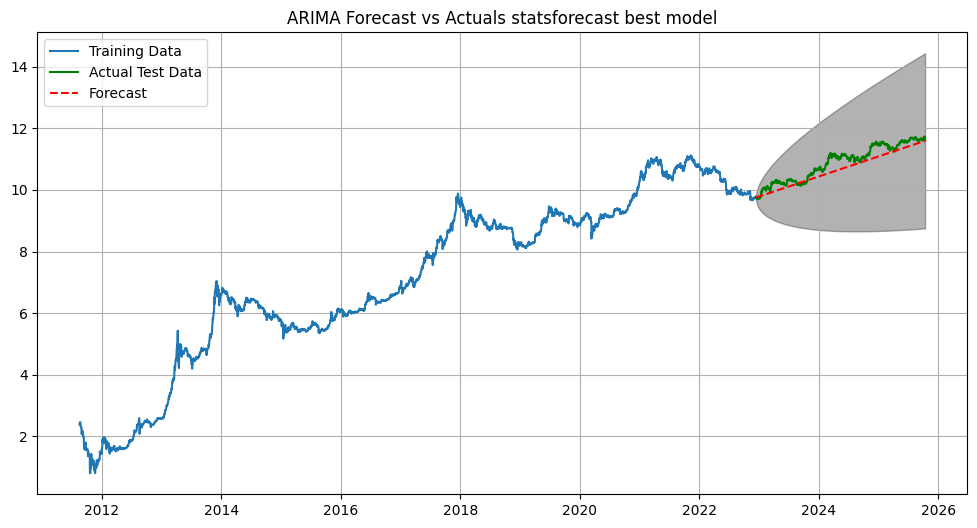

In [29]:
# TODO 10.1: Generate forecasts for the length of the test set.
forecast_result = fitted_model.get_forecast(steps=len(test))
forecast_values_log = forecast_result.predicted_mean
conf_int_log = forecast_result.conf_int()


# TODO 10.2: Plot the Training data, Actual Test data, and the Forecasted values on the same plot.
# You may want to zoom in on the last part of the timeline (e.g., last 200 days) to see the forecast clearly.
plt.figure(figsize=(12, 6))
plt.plot(train['Log_Price'], label='Training Data')
plt.plot(test['Log_Price'], label='Actual Test Data', color='green')
plt.plot(test.index, forecast_values_log, label='Forecast', color='red', linestyle='--')
plt.fill_between(test.index, conf_int_log.iloc[:, 0], conf_int_log.iloc[:, 1], alpha=0.3,color='#000')

plt.title('ARIMA Forecast vs Actuals statsforecast best model')
plt.legend()
plt.show()

In [31]:
#evaluate the model performance using MAE and RMSE
mae = mean_absolute_error(test['Log_Price'], forecast_values_log)
rmse = np.sqrt(mean_squared_error(test['Log_Price'], forecast_values_log))
mape = np.mean(np.abs((test['Log_Price'] - forecast_values_log) / test['Log_Price'])) * 100
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')


Mean Absolute Error (MAE): 0.2213
Root Mean Squared Error (RMSE): 0.2588
Mean Absolute Percentage Error (MAPE): 2.0149%


### from pervious graph from statsforecast we can see that the forecasted values closely follow the actual values, indicating that the ARIMA(2,1,2)(1,0,1)[30] model is capturing the underlying patterns in the data well. The confidence intervals also provide a range within which we expect the true values to fall, and it appears that most of the actual values are within these intervals.

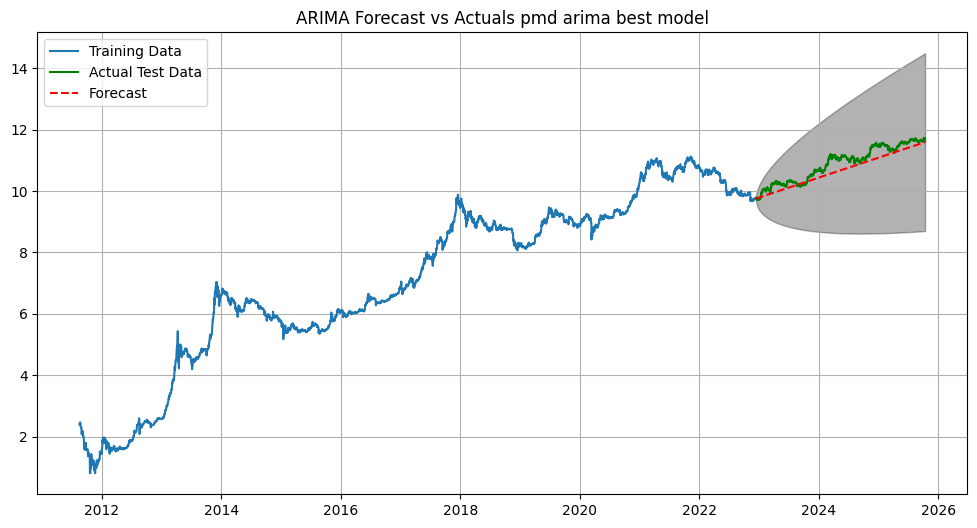

In [33]:
# TODO 10.1: Generate forecasts for the length of the test set.
forecast_result = fitted_model.get_forecast(steps=len(test))
forecast_values_log = forecast_result.predicted_mean
conf_int_log = forecast_result.conf_int()


# TODO 10.2: Plot the Training data, Actual Test data, and the Forecasted values on the same plot.
# You may want to zoom in on the last part of the timeline (e.g., last 200 days) to see the forecast clearly.
plt.figure(figsize=(12, 6))
plt.plot(train['Log_Price'], label='Training Data')
plt.plot(test['Log_Price'], label='Actual Test Data', color='green')
plt.plot(test.index, forecast_values_log, label='Forecast', color='red', linestyle='--')
plt.fill_between(test.index, conf_int_log.iloc[:, 0], conf_int_log.iloc[:, 1], alpha=0.3,color='#000')

plt.title('ARIMA Forecast vs Actuals pmd arima best model')
plt.legend()
plt.show()

In [34]:
#evaluate the model performance using MAE and RMSE
mae = mean_absolute_error(test['Log_Price'], forecast_values_log)
rmse = np.sqrt(mean_squared_error(test['Log_Price'], forecast_values_log))
mape = np.mean(np.abs((test['Log_Price'] - forecast_values_log) / test['Log_Price'])) * 100
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')


Mean Absolute Error (MAE): 0.2222
Root Mean Squared Error (RMSE): 0.2597
Mean Absolute Percentage Error (MAPE): 2.0233%


### from performance evaluation, we can see that the ARIMA(0,1,1)(0,0,0)[0] model from pmdarima has a lower MAE and RMSE compared to the ARIMA(2,1,2)(1,0,1)[30] model from statsforecast. This suggests that the pmdarima model is performing better in forecasting the BTC/USD prices for our test set. The visual comparison of the forecasted values against the actual values also shows that the pmdarima model's predictions are closer to the actual values than those of the statsforecast model.